In [1]:
import sys, os, time, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

try:
    from dtaidistance import dtw
except ImportError:
    if "google.colab" in sys.modules:
        os.system("pip install -q dtaidistance")
    else:
        os.system("pip install -q dtaidistance --break-system-packages")
    from dtaidistance import dtw

from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score
from sklearn.manifold import MDS

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("Ready.")

Ready.


In [2]:
if "google.colab" in sys.modules:
    from google.colab import files
    uploaded = files.upload()
    FILENAME = list(uploaded.keys())[0]
else:
    FILENAME = "ftse250_clustering_ready.csv"
print("Using file:", FILENAME)

Saving ftse250_clustering_ready.csv to ftse250_clustering_ready.csv
Using file: ftse250_clustering_ready.csv


In [3]:

MAX_MISSING_FRAC = 0.10

df = pd.read_csv(FILENAME)
date_cols = [c for c in df.columns if c != "Ticker"]

frac = df[date_cols].isna().sum(axis=1) / len(date_cols)
dropped = df.loc[frac > MAX_MISSING_FRAC, "Ticker"].tolist()
df = df.loc[frac <= MAX_MISSING_FRAC].reset_index(drop=True)

n_filled = int(df[date_cols].isna().sum().sum())
df[date_cols] = df[date_cols].ffill(axis=1).bfill(axis=1)

tickers = df["Ticker"].values
A = df[date_cols].values.astype(float)
dates = pd.to_datetime(date_cols)

print(f"Dropped (>10% missing) : {len(dropped)} {dropped}")
print(f"Single gaps filled     : {n_filled}")
print(f"Stocks retained        : {len(df)}")
print(f"Trading days            : {len(date_cols)}")
print(f"Date range              : {date_cols[0]} to {date_cols[-1]}")
assert df[date_cols].isna().sum().sum() == 0

Dropped (>10% missing) : 0 []
Single gaps filled     : 4
Stocks retained        : 241
Trading days            : 1153
Date range              : 2021-11-30 to 2026-06-29


In [4]:

COMPRESS_FOR_DTW = False
TARGET_POINTS = 250

def paa_compress(A, target_points):
    n, T = A.shape
    if T <= target_points:
        return A
    bounds = np.linspace(0, T, target_points + 1).astype(int)
    return np.column_stack([
        A[:, bounds[i]:max(bounds[i] + 1, bounds[i + 1])].mean(axis=1)
        for i in range(target_points)
    ])

A_dtw = paa_compress(A, TARGET_POINTS) if COMPRESS_FOR_DTW else A
print(f"Series length used for DTW: {A_dtw.shape[1]}" +
      ("  (PAA-compressed)" if COMPRESS_FOR_DTW else "  (full resolution)"))

Series length used for DTW: 1153  (full resolution)


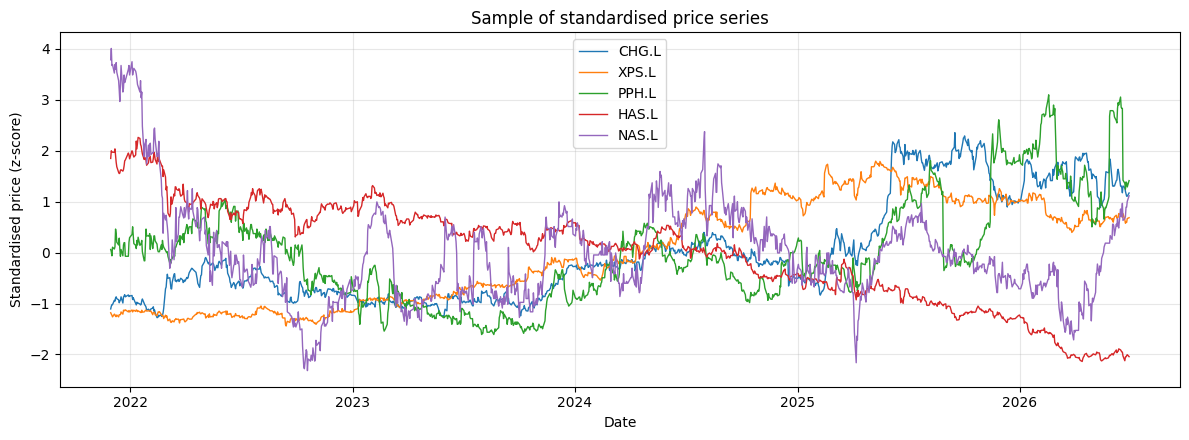

In [5]:

idx = np.random.default_rng(RANDOM_STATE).choice(len(tickers), 5, replace=False)
fig, ax = plt.subplots(figsize=(12, 4.5))
for i in idx:
    ax.plot(dates, A[i], linewidth=1, label=tickers[i])
ax.set_title("Sample of standardised price series")
ax.set_xlabel("Date"); ax.set_ylabel("Standardised price (z-score)")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(); plt.tight_layout(); plt.show()

In [6]:

WINDOW_FRAC = 0.05
MIN_WINDOW = 10

T = A_dtw.shape[1]
WINDOW = max(MIN_WINDOW, int(WINDOW_FRAC * T))

t0 = time.time()
D = dtw.distance_matrix_fast(A_dtw, window=WINDOW)
D = np.maximum(D, D.T)
np.fill_diagonal(D, 0.0)
print(f"DTW distance matrix computed in {time.time()-t0:.1f}s")
print(f"Series length: {T}, window: {WINDOW} days")
print(f"Distance matrix shape: {D.shape}")
print(f"Distance range: [{D.min():.3f}, {D.max():.3f}], mean {D[D>0].mean():.3f}")

DTW distance matrix computed in 32.7s
Series length: 1153, window: 57 days
Distance matrix shape: (241, 241)
Distance range: [0.000, 66.452], mean 34.979


In [7]:


def _kmedoids_plusplus_init(D, k, rng):
    n = D.shape[0]
    medoids = [int(rng.integers(n))]
    for _ in range(1, k):
        dist_to_nearest = D[:, medoids].min(axis=1)
        probs = dist_to_nearest ** 2
        s = probs.sum()
        probs = probs / s if s > 0 else np.ones(n) / n
        medoids.append(int(rng.choice(n, p=probs)))
    return np.array(medoids)


def kmedoids_pam(D, k, n_init=10, max_iter=100, random_state=RANDOM_STATE):
    rng = np.random.default_rng(random_state)
    n = D.shape[0]
    best_cost, best_medoids, best_labels = np.inf, None, None
    for init in range(n_init):
        medoids = _kmedoids_plusplus_init(D, k, rng)
        for _ in range(max_iter):
            labels = np.argmin(D[:, medoids], axis=1)
            new_medoids = medoids.copy()
            changed = False
            for ci in range(k):
                members = np.where(labels == ci)[0]
                if len(members) == 0:
                    continue
                costs = D[np.ix_(members, members)].sum(axis=1)
                best_local = members[np.argmin(costs)]
                if best_local != new_medoids[ci]:
                    new_medoids[ci] = best_local
                    changed = True
            if not changed:
                break
            medoids = new_medoids
        labels = np.argmin(D[:, medoids], axis=1)
        cost = D[np.arange(n), medoids[labels]].sum()
        if cost < best_cost:
            best_cost, best_medoids, best_labels = cost, medoids.copy(), labels.copy()
    return best_medoids, best_labels, best_cost


def dunn_index(D, labels):

    clusters = np.unique(labels)
    intra_max = 0.0
    for c in clusters:
        idx = np.where(labels == c)[0]
        if len(idx) > 1:
            intra_max = max(intra_max, D[np.ix_(idx, idx)].max())
    inter_min = np.inf
    for i, ci in enumerate(clusters):
        for cj in clusters[i + 1:]:
            idx_i = np.where(labels == ci)[0]
            idx_j = np.where(labels == cj)[0]
            inter_min = min(inter_min, D[np.ix_(idx_i, idx_j)].min())
    return inter_min / intra_max if intra_max > 0 else np.nan


def davies_bouldin_distmat(D, labels, medoids):

    k = len(medoids)
    S = np.array([D[np.where(labels == ci)[0], medoids[ci]].mean() for ci in range(k)])
    total = 0.0
    for ci in range(k):
        best = 0.0
        for cj in range(k):
            if ci == cj:
                continue
            d_ij = D[medoids[ci], medoids[cj]]
            ratio = (S[ci] + S[cj]) / d_ij if d_ij > 0 else np.inf
            best = max(best, ratio)
        total += best
    return total / k


def bootstrap_stability_dm(D, k, B=30, frac=0.8, seed=RANDOM_STATE, n_init=3):

    rng = np.random.default_rng(seed)
    n = D.shape[0]
    m = int(frac * n)
    idxs, labs = [], []
    for b in range(B):
        idx = rng.choice(n, m, replace=False)
        sub = D[np.ix_(idx, idx)]
        _, lab, _ = kmedoids_pam(sub, k, n_init=n_init, random_state=seed + b)
        idxs.append(idx); labs.append(lab)
    maps = [dict(zip(i, l)) for i, l in zip(idxs, labs)]
    aris = []
    for i in range(B):
        for j in range(i + 1, B):
            common = np.intersect1d(idxs[i], idxs[j])
            if len(common) < 10:
                continue
            aris.append(adjusted_rand_score([maps[i][c] for c in common],
                                             [maps[j][c] for c in common]))
    return (float(np.mean(aris)), float(np.min(aris))) if aris else (np.nan, np.nan)


print("Functions defined.")

Functions defined.


In [8]:
K_RANGE = range(2, 11)
N_BOOTSTRAP = 30
STABILITY_FLOOR = 0.60

t0 = time.time()
rows = []
for k in K_RANGE:
    medoids_k, labels_k, cost_k = kmedoids_pam(D, k, n_init=10)
    stab, stab_min = bootstrap_stability_dm(D, k, B=N_BOOTSTRAP)
    rows.append({
        "k": k,
        "silhouette": silhouette_score(D, labels_k, metric="precomputed"),
        "dunn": dunn_index(D, labels_k),
        "davies_bouldin": davies_bouldin_distmat(D, labels_k, medoids_k),
        "stability": stab,
        "stability_min": stab_min,
        "smallest_cluster": int(np.bincount(labels_k, minlength=k).min()),
    })

metrics = pd.DataFrame(rows)
print(f"Computed in {time.time()-t0:.0f}s\n")
display(metrics.round(4))

Computed in 6s



,k,silhouette,dunn,davies_bouldin,stability,stability_min,smallest_cluster
0,2,0.4140,0.1094,0.6926,0.9380,0.8284,103
1,3,0.3383,0.1077,1.2474,0.5846,0.3152,61
2,4,0.2505,0.0737,1.5840,0.5400,0.2999,49
3,5,0.2440,0.0811,1.4172,0.5646,0.3102,22
4,6,0.2396,0.0815,1.5668,0.5467,0.2899,21
5,7,0.2245,0.0831,1.3465,0.5283,0.3099,13
6,8,0.2117,0.0485,1.4838,0.5425,0.3542,10
7,9,0.2050,0.0926,1.3903,0.5481,0.3127,11
8,10,0.1693,0.0711,1.5299,0.5059,0.3056,10


In [9]:
metrics["r_sil"] = metrics["silhouette"].rank(ascending=False)
metrics["r_dun"] = metrics["dunn"].rank(ascending=False)
metrics["r_dav"] = metrics["davies_bouldin"].rank(ascending=True)
metrics["r_sta"] = metrics["stability"].rank(ascending=False)
metrics["mean_rank"] = metrics[["r_sil", "r_dun", "r_dav", "r_sta"]].mean(axis=1)

admissible = metrics[metrics["stability"] >= STABILITY_FLOOR]
if len(admissible) == 0:
    print(f"WARNING: no k reaches the stability floor of {STABILITY_FLOOR}.")
    print("There is no reliable cluster structure in this representation.")
    admissible = metrics

consensus_k = int(admissible.sort_values("mean_rank").iloc[0]["k"])

print(f"Silhouette alone would pick k = {int(metrics.loc[metrics['silhouette'].idxmax(), 'k'])}")
print(f"Dunn Index alone would pick   k = {int(metrics.loc[metrics['dunn'].idxmax(), 'k'])}")
print(f"Consensus of all four         k = {consensus_k}")
print(f"\nStability at consensus k      : {float(metrics.loc[metrics['k']==consensus_k,'stability'].iloc[0]):.3f}")

Silhouette alone would pick k = 2
Dunn Index alone would pick   k = 2
Consensus of all four         k = 2

Stability at consensus k      : 0.938


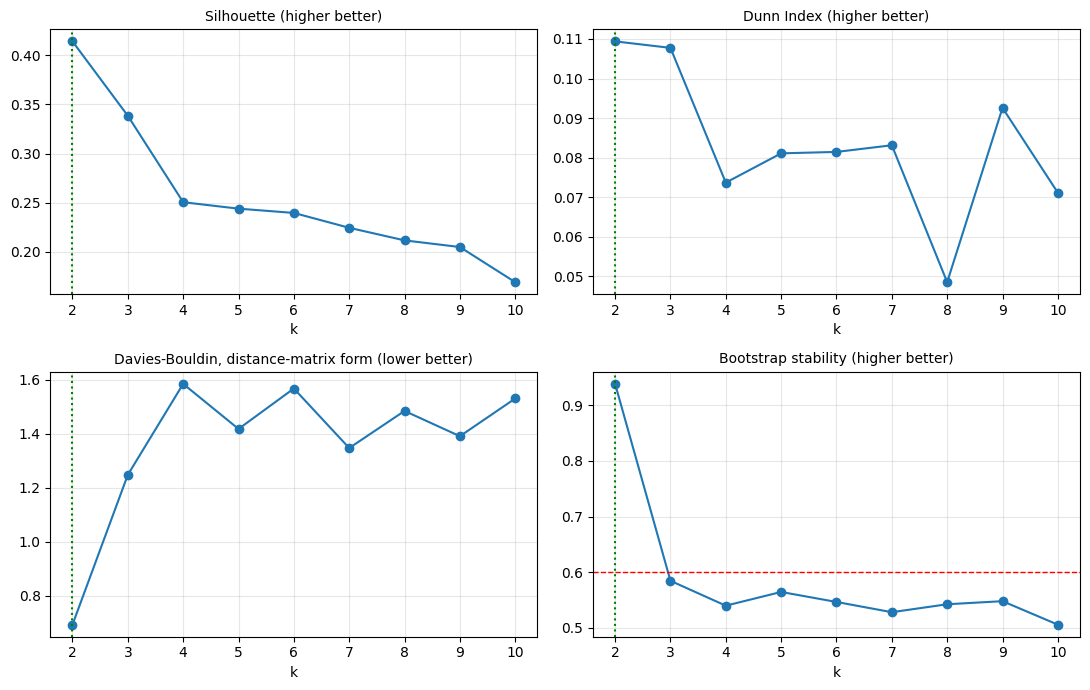

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
specs = [("silhouette", "Silhouette (higher better)"),
         ("dunn", "Dunn Index (higher better)"),
         ("davies_bouldin", "Davies-Bouldin, distance-matrix form (lower better)"),
         ("stability", "Bootstrap stability (higher better)")]

for ax, (col, title) in zip(axes.flat, specs):
    ax.plot(metrics["k"], metrics[col], marker="o")
    ax.axvline(consensus_k, color="green", ls=":", lw=1.5)
    ax.set_title(title, fontsize=10); ax.set_xlabel("k")
    if col == "stability":
        ax.axhline(STABILITY_FLOOR, color="red", ls="--", lw=1)

plt.tight_layout(); plt.show()

In [11]:
FINAL_K = consensus_k

medoids, labels, cost = kmedoids_pam(D, FINAL_K, n_init=20)
stab, stab_min = bootstrap_stability_dm(D, FINAL_K, B=N_BOOTSTRAP)

print("=" * 50)
print(f"  DATASET     : {FILENAME}")
print(f"  Stocks      : {len(tickers)}")
print(f"  Distance    : DTW, window={WINDOW} ({WINDOW_FRAC:.0%} of series length)")
print(f"  k           : {FINAL_K}")
print("-" * 50)
print(f"  Silhouette     : {silhouette_score(D, labels, metric='precomputed'):.4f}")
print(f"  Dunn Index     : {dunn_index(D, labels):.4f}")
print(f"  Davies-Bouldin : {davies_bouldin_distmat(D, labels, medoids):.4f}")
print(f"  Stability      : {stab:.4f}  (worst pair {stab_min:.3f})")
print("-" * 50)
print(f"  Cluster sizes  : {np.bincount(labels).tolist()}")
print(f"  Medoid tickers : {list(tickers[medoids])}")
print("=" * 50)

  DATASET     : ftse250_clustering_ready.csv
  Stocks      : 241
  Distance    : DTW, window=57 (5% of series length)
  k           : 2
--------------------------------------------------
  Silhouette     : 0.4140
  Dunn Index     : 0.1094
  Davies-Bouldin : 0.6926
  Stability      : 0.9380  (worst pair 0.828)
--------------------------------------------------
  Cluster sizes  : [103, 138]
  Medoid tickers : ['DLN.L', 'ESCT.L']


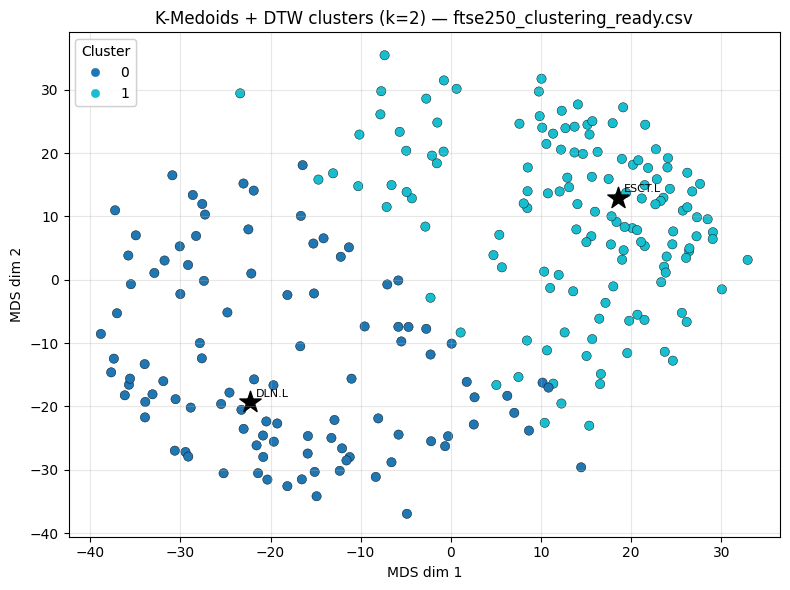

In [12]:

mds = MDS(n_components=2, dissimilarity="precomputed", random_state=RANDOM_STATE,
          normalized_stress=False)
V = mds.fit_transform(D)

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(V[:, 0], V[:, 1], c=labels, cmap="tab10", s=45, edgecolor="k", linewidth=0.3)
ax.scatter(V[medoids, 0], V[medoids, 1], marker="*", s=260, c="black", label="medoids")
for m in medoids:
    ax.annotate(tickers[m], (V[m, 0], V[m, 1]), fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.set_title(f"K-Medoids + DTW clusters (k={FINAL_K}) — {FILENAME}")
ax.set_xlabel("MDS dim 1"); ax.set_ylabel("MDS dim 2")
ax.add_artist(ax.legend(*sc.legend_elements(), title="Cluster", loc="upper left"))
plt.tight_layout(); plt.show()

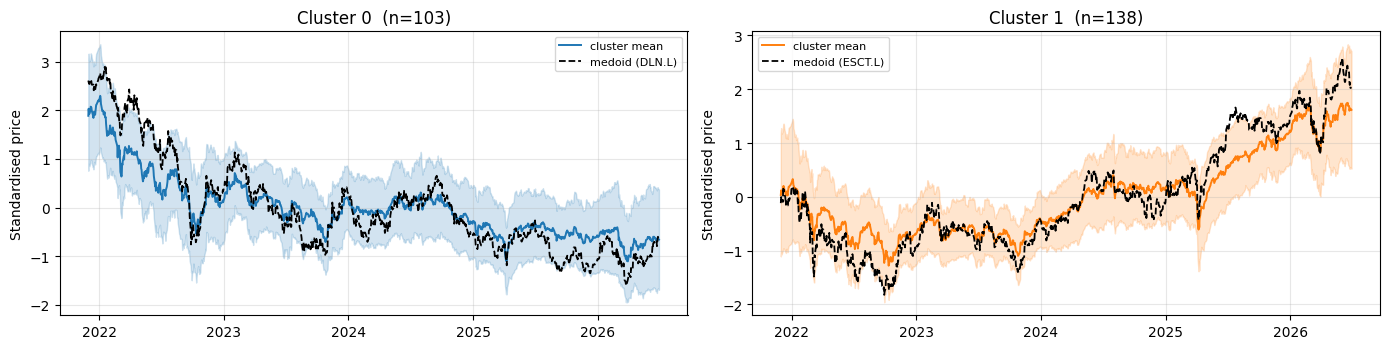

In [13]:
n_cols = 2
n_rows = int(np.ceil(FINAL_K / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.6 * n_rows), squeeze=False)

for c in range(FINAL_K):
    ax = axes[c // n_cols][c % n_cols]
    mem = A[labels == c]
    mu, sd = mem.mean(axis=0), mem.std(axis=0)
    ax.plot(dates, mu, color=f"C{c}", lw=1.4, label="cluster mean")
    ax.fill_between(dates, mu - sd, mu + sd, color=f"C{c}", alpha=0.2)
    ax.plot(dates, A[medoids[c]], color="black", lw=1.3, ls="--", label=f"medoid ({tickers[medoids[c]]})")
    ax.set_title(f"Cluster {c}  (n={len(mem)})")
    ax.set_ylabel("Standardised price")
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.legend(fontsize=8)

for c in range(FINAL_K, n_rows * n_cols):
    axes[c // n_cols][c % n_cols].axis("off")
plt.tight_layout(); plt.show()

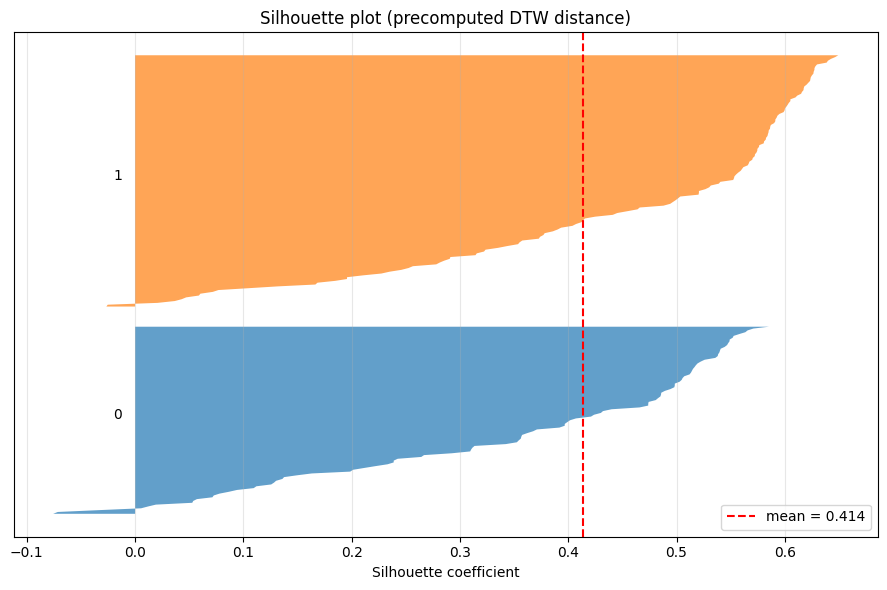

In [14]:
sv = silhouette_samples(D, labels, metric="precomputed")
fig, ax = plt.subplots(figsize=(9, 6))
y = 10
for c in range(FINAL_K):
    v = np.sort(sv[labels == c])
    ax.fill_betweenx(np.arange(y, y + len(v)), 0, v, facecolor=f"C{c}", alpha=0.7)
    ax.text(-0.02, y + 0.5 * len(v), str(c))
    y += len(v) + 10
ax.axvline(sv.mean(), color="red", ls="--", label=f"mean = {sv.mean():.3f}")
ax.set_title("Silhouette plot (precomputed DTW distance)"); ax.set_xlabel("Silhouette coefficient")
ax.set_yticks([]); ax.legend(); plt.tight_layout(); plt.show()

In [15]:
import textwrap
for c in range(FINAL_K):
    mem = sorted(tickers[labels == c])
    print(f"Cluster {c} (n={len(mem)}, medoid={tickers[medoids[c]]}):")
    labelled = [f"*{t}*" if t == tickers[medoids[c]] else t for t in mem]
    print(textwrap.fill(", ".join(labelled), width=95))
    print()

Cluster 0 (n=103, medoid=DLN.L):
AML.L, ASHM.L, BHMG.L, BKG.L, BME.L, BPT.L, BREE.L, BRSC.L, BSIF.L, BWY.L, BYG.L, BYIT.L,
CBG.L, CGT.L, CVSG.L, CWR.L, DATA.L, *DLN.L*, DNLM.L, DOCS.L, DOM.L, DSCV.L, ENOG.L, EZJ.L,
FGEN.L, FGT.L, FRAS.L, GAMA.L, GBG.L, GCP.L, GEN.L, GFTU.L, GNS.L, GPE.L, GRG.L, GRI.L, GROW.L,
HAS.L, HFEL.L, HFG.L, HICL.L, HIK.L, HSL.L, IHP.L, INCH.L, INPP.L, IPO.L, ITV.L, IWG.L, JDW.L,
JUP.L, KNOS.L, MGAM.L, MNDI.L, MONY.L, N91.L, NAS.L, NBPE.L, NCC.L, OCDO.L, ONT.L, PAGE.L,
PETS.L, PHP.L, PNN.L, PTEC.L, RCP.L, RHIM.L, RICA.L, RMV.L, RS1.L, RSW.L, SAFE.L, SEIT.L,
SEQI.L, SHC.L, SMWH.L, SPI.L, SRE.L, SSPG.L, SUPR.L, SVS.L, SYNC.L, TATE.L, TEP.L, THG.L,
THRL.L, TPK.L, TRIG.L, TRN.L, TRY.L, TW.L, UKW.L, UTG.L, VCT.L, VOF.L, VTY.L, WIZZ.L, WKP.L,
WOSG.L, WPP.L, XPP.L, ZIG.L

Cluster 1 (n=138, medoid=ESCT.L):
3IN.L, AAS.L, AEP.L, AGT.L, AIE.L, AJB.L, ALFA.L, AO.L, ASL.L, ATR.L, ATT.L, ATYM.L, AVON.L,
BAG.L, BBY.L, BCG.L, BGFD.L, BMY.L, BNKR.L, BOWL.L, BOY.L, BPCR.L, BRGE.L,

In [16]:
t_idx = np.arange(A.shape[1])
slopes = np.array([np.polyfit(t_idx, row, 1)[0] for row in A])
trend_sign = (slopes > 0).astype(int)

ari_trend = adjusted_rand_score(labels, trend_sign)
print(f"ARI between clusters and sign-of-trend: {ari_trend:.3f}")
print()
if ari_trend > 0.7:
    print("=> The clustering is largely a restatement of trend direction.")
elif ari_trend > 0.3:
    print("=> Trend explains part of the clustering, but not all of it.")
else:
    print("=> The clustering is capturing something beyond trend direction.")

print(f"\nStocks trending up: {trend_sign.sum()} / down: {(1-trend_sign).sum()}")
print("\nMean slope per cluster:")
for c in range(FINAL_K):
    print(f"  Cluster {c}: {slopes[labels == c].mean():+.6f}")

ARI between clusters and sign-of-trend: 0.795

=> The clustering is largely a restatement of trend direction.

Stocks trending up: 139 / down: 102

Mean slope per cluster:
  Cluster 0: -0.001541
  Cluster 1: +0.001819


In [17]:
def logistic_weight(r, mu, s):
    z = (r - mu) / s
    return np.exp(-z) / (s * (1 + np.exp(-z)) ** 2)

def lwdtw_distance(x, y, window=None):

    n, m = len(x), len(y)
    window = window or max(n, m)
    rx = np.diff(x, prepend=x[0])
    ry = np.diff(y, prepend=y[0])
    all_r = np.concatenate([rx, ry])
    mu, s = all_r.mean(), all_r.std() * np.sqrt(3) / np.pi

    INF = np.inf
    Dm = np.full((n + 1, m + 1), INF)
    Dm[0, 0] = 0.0
    for i in range(1, n + 1):
        lo, hi = max(1, i - window), min(m, i + window)
        for j in range(lo, hi + 1):
            cost = (x[i - 1] - y[j - 1]) ** 2
            w = logistic_weight(0.5 * (rx[i - 1] + ry[j - 1]), mu, s)
            Dm[i, j] = w * cost + min(Dm[i - 1, j], Dm[i, j - 1], Dm[i - 1, j - 1])
    return np.sqrt(Dm[n, m])